# Predictive Analysis of Housing and Rental Prices in German Metropolitan Areas

**M516 Business Project in Big Data & AI — Gisma University of Applied Sciences**
**Student:** Kunal Singh (GH1039524)

This notebook contains the full, runnable implementation of the project: synthetic data generation,
exploratory data analysis, feature engineering, model training, model comparison, and per-city
evaluation of housing price predictions across eight major German cities. It mirrors `analysis.py`
in this repository — see the `README.md` for the project write-up (Introduction, System Architecture,
Implementation, Challenges & Solutions, Results, Conclusion & Future Work).

## Implementation Pipeline

![Implementation pipeline](outputs/implementation_flow.png)

The cells below follow this pipeline exactly, in order.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('outputs', exist_ok=True)

pd.set_option('display.max_columns', None)
print("Housing Price Prediction - German Metropolitan Areas")

Housing Price Prediction - German Metropolitan Areas


## 1. Data Generation

The dataset consists of 2,000 synthetic property listings modelled on documented German market
statistics (Statista, IW Köln 2023 reports), covering eight cities: Berlin, Munich, Frankfurt,
Hamburg, Cologne, Stuttgart, Düsseldorf and Leipzig. Ten input features describe each property
(size, rooms, age, floor, balcony/parking/elevator, distance to city centre, district quality
score); the targets are price per sqm (€) and monthly rent (€).

In [2]:
np.random.seed(42)
N = 2000

cities = ['Berlin', 'Munich', 'Frankfurt', 'Hamburg',
          'Cologne', 'Stuttgart', 'Düsseldorf', 'Leipzig']

city_base_price = {
    'Berlin': 5200, 'Munich': 9800, 'Frankfurt': 7100,
    'Hamburg': 6800, 'Cologne': 5500, 'Stuttgart': 6200,
    'Düsseldorf': 5900, 'Leipzig': 3400
}
city_weights = [0.20, 0.18, 0.14, 0.14, 0.12, 0.08, 0.08, 0.06]

city_col      = np.random.choice(cities, size=N, p=city_weights)
size_sqm      = np.random.normal(75, 25, N).clip(25, 250)
rooms         = np.round(size_sqm / 30).clip(1, 8).astype(int)
age_years     = np.random.choice(range(0, 80), N)
floor         = np.random.randint(0, 12, N)
has_balcony   = np.random.binomial(1, 0.55, N)
has_parking   = np.random.binomial(1, 0.40, N)
has_elevator  = (floor > 3).astype(int)
distance_cbd  = np.random.exponential(8, N).clip(0.5, 40)
district_score = np.random.uniform(1, 10, N)

base = np.array([city_base_price[c] for c in city_col])
price_per_sqm = (
    base
    + district_score * 180
    - age_years * 22
    + has_balcony * 300
    + has_parking * 400
    + has_elevator * 200
    - distance_cbd * 80
    + floor * 50
    + np.random.normal(0, 600, N)
).clip(1500, 18000)

rent_per_sqm = (price_per_sqm / 280).clip(6, 45)

total_price = (price_per_sqm * size_sqm).round(-2)
monthly_rent = (rent_per_sqm * size_sqm).round()

df = pd.DataFrame({
    'city': city_col,
    'size_sqm': size_sqm.round(1),
    'rooms': rooms,
    'age_years': age_years,
    'floor': floor,
    'has_balcony': has_balcony,
    'has_parking': has_parking,
    'has_elevator': has_elevator,
    'distance_cbd_km': distance_cbd.round(2),
    'district_score': district_score.round(2),
    'price_per_sqm': price_per_sqm.round(2),
    'total_price_eur': total_price,
    'monthly_rent_eur': monthly_rent
})

print(f"Dataset created: {len(df)} listings across {df['city'].nunique()} cities")
df.head()

Dataset created: 2000 listings across 8 cities


,city,size_sqm,rooms,age_years,floor,has_balcony,has_parking,has_elevator,distance_cbd_km,district_score,price_per_sqm,total_price_eur,monthly_rent_eur
0,Munich,53.1,2,16,10,0,0,1,4.73,3.49,9874.14,523800.0,1871.0
1,Leipzig,54.3,2,27,3,1,1,0,9.49,7.43,4164.17,226200.0,808.0
2,Cologne,69.3,2,40,0,0,0,0,0.66,4.46,4711.80,326700.0,1167.0
3,Hamburg,84.2,3,65,8,1,1,1,7.22,7.94,7753.91,652800.0,2331.0
4,Berlin,97.8,3,24,5,0,1,1,7.12,2.29,5498.25,537900.0,1921.0


In [3]:
df.describe().round(2)

,size_sqm,rooms,age_years,floor,has_balcony,has_parking,has_elevator,distance_cbd_km,district_score,price_per_sqm,total_price_eur,monthly_rent_eur
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,75.42,2.52,40.03,5.58,0.53,0.39,0.67,7.95,5.50,6723.55,506538.95,1808.95
std,24.48,0.86,23.33,3.50,0.50,0.49,0.47,7.43,2.59,2099.07,233034.48,831.70
min,25.00,1.00,0.00,0.00,0.00,0.00,0.00,0.50,1.00,1500.00,83200.00,297.00
25%,58.50,2.00,20.00,3.00,0.00,0.00,0.00,2.44,3.25,5334.83,337050.00,1203.75
50%,75.00,3.00,41.00,6.00,1.00,0.00,1.00,5.77,5.47,6467.56,473600.00,1691.50
75%,92.00,3.00,60.00,9.00,1.00,1.00,1.00,11.12,7.69,7925.92,645225.00,2304.50
max,173.20,6.00,79.00,11.00,1.00,1.00,1.00,40.00,10.00,13199.76,1391100.00,4968.00


## 2. Exploratory Data Analysis

Munich commands the highest average price per sqm (~€9,800), followed by Frankfurt and Hamburg;
Leipzig is the most affordable market (~€3,400/sqm). The correlation matrix shows district
quality score as the strongest positive predictor of price, and distance from the city centre /
property age as the strongest negative predictors.

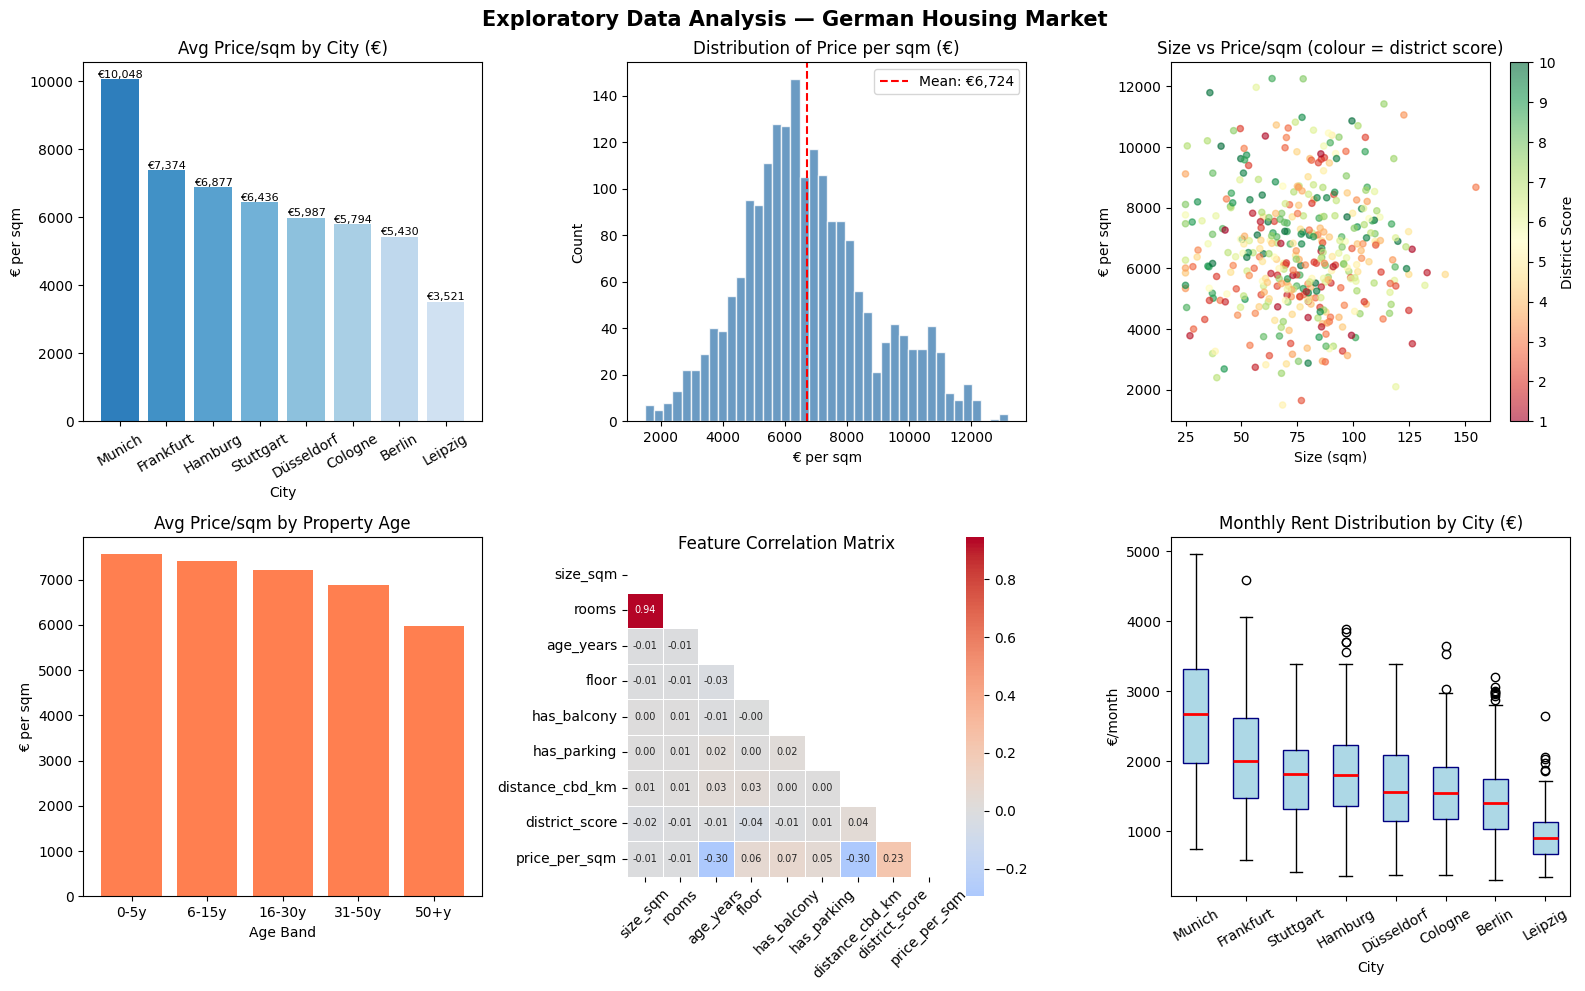

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — German Housing Market', fontsize=15, fontweight='bold')

city_avg = df.groupby('city')['price_per_sqm'].mean().sort_values(ascending=False)
axes[0,0].bar(city_avg.index, city_avg.values, color=plt.cm.Blues_r(np.linspace(0.3,0.8,len(city_avg))))
axes[0,0].set_title('Avg Price/sqm by City (€)')
axes[0,0].set_xlabel('City')
axes[0,0].set_ylabel('€ per sqm')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(city_avg.values):
    axes[0,0].text(i, v+50, f'€{v:,.0f}', ha='center', fontsize=8)

axes[0,1].hist(df['price_per_sqm'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].axvline(df['price_per_sqm'].mean(), color='red', linestyle='--', label=f'Mean: €{df["price_per_sqm"].mean():,.0f}')
axes[0,1].set_title('Distribution of Price per sqm (€)')
axes[0,1].set_xlabel('€ per sqm')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

sample = df.sample(400, random_state=42)
scatter = axes[0,2].scatter(sample['size_sqm'], sample['price_per_sqm'],
                             c=sample['district_score'], cmap='RdYlGn', alpha=0.6, s=20)
axes[0,2].set_title('Size vs Price/sqm (colour = district score)')
axes[0,2].set_xlabel('Size (sqm)')
axes[0,2].set_ylabel('€ per sqm')
plt.colorbar(scatter, ax=axes[0,2], label='District Score')

age_bins = pd.cut(df['age_years'], bins=[0,5,15,30,50,80], labels=['0-5y','6-15y','16-30y','31-50y','50+y'])
age_price = df.groupby(age_bins)['price_per_sqm'].mean()
axes[1,0].bar(age_price.index.astype(str), age_price.values, color='coral')
axes[1,0].set_title('Avg Price/sqm by Property Age')
axes[1,0].set_xlabel('Age Band')
axes[1,0].set_ylabel('€ per sqm')

num_cols = ['size_sqm','rooms','age_years','floor','has_balcony','has_parking',
            'distance_cbd_km','district_score','price_per_sqm']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[1,1], mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5, annot_kws={'size':7})
axes[1,1].set_title('Feature Correlation Matrix')
axes[1,1].tick_params(axis='x', rotation=45)

city_order = df.groupby('city')['monthly_rent_eur'].median().sort_values(ascending=False).index
bp_data = [df[df['city']==c]['monthly_rent_eur'].values for c in city_order]
axes[1,2].boxplot(bp_data, labels=city_order, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', color='navy'),
                  medianprops=dict(color='red', linewidth=2))
axes[1,2].set_title('Monthly Rent Distribution by City (€)')
axes[1,2].set_xlabel('City')
axes[1,2].set_ylabel('€/month')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering & Preprocessing

The categorical `city` feature is label-encoded (chosen over one-hot encoding because the dataset
is relatively small — one-hot would add 7 sparse columns for little gain, and Gradient Boosting is
robust to label-encoded nominal features given 200 estimators). Features are standardised with
`StandardScaler` for the linear models only; tree-based models use raw features since they are
scale-invariant. An 80/20 train-test split is used with a fixed random seed (42) for
reproducibility.

In [5]:
le = LabelEncoder()
df['city_encoded'] = le.fit_transform(df['city'])

features = ['city_encoded','size_sqm','rooms','age_years','floor',
            'has_balcony','has_parking','has_elevator',
            'distance_cbd_km','district_score']
target = 'price_per_sqm'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 1600 | Test: 400


## 4. Model Training

Four regression algorithms are trained and evaluated: Linear Regression (baseline), Ridge
Regression (regularised linear), Random Forest (bagging ensemble) and Gradient Boosting (boosting
ensemble, regularised with `learning_rate=0.08` and `max_depth=5` to limit overfitting).

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.08, max_depth=5, random_state=42)
}

results = {}
for name, model in models.items():
    if 'Regression' in name:
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'preds': preds}
    print(f"{name:25s} | MAE: €{mae:,.0f} | RMSE: €{rmse:,.0f} | R²: {r2:.4f}")

Linear Regression         | MAE: €1,132 | RMSE: €1,608 | R²: 0.3481
Ridge Regression          | MAE: €1,132 | RMSE: €1,606 | R²: 0.3492


Random Forest             | MAE: €587 | RMSE: €713 | R²: 0.8718


Gradient Boosting         | MAE: €541 | RMSE: €653 | R²: 0.8924


## 5. Model Comparison

Tree-based models substantially outperform the linear baselines, confirming that non-linear
relationships exist in the data that Linear/Ridge Regression cannot capture.

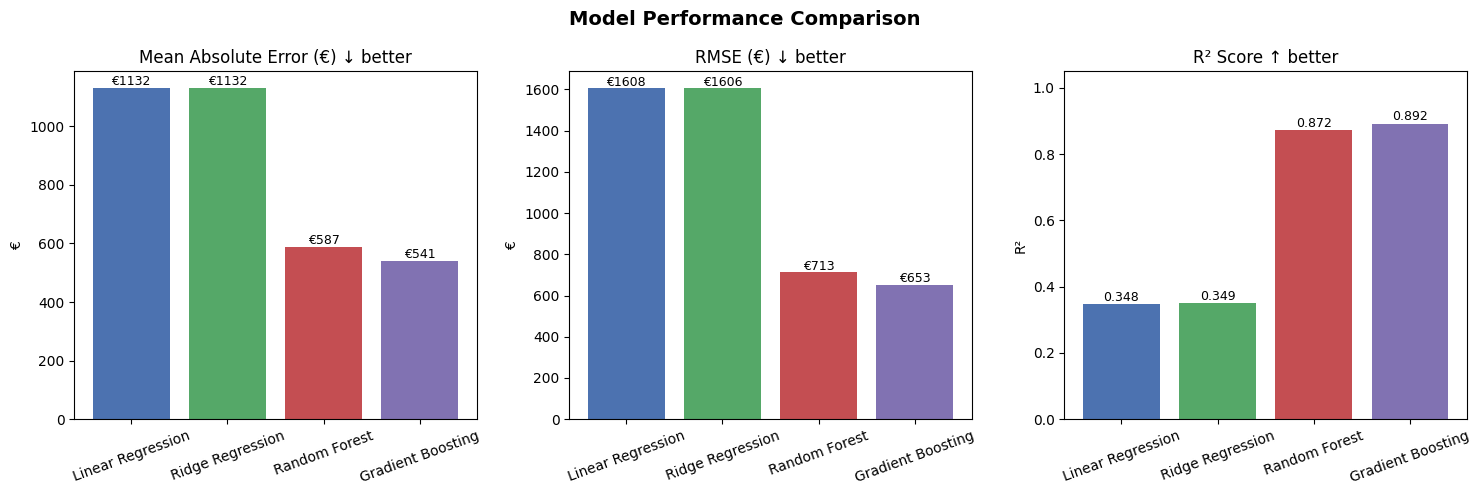

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

names = list(results.keys())
maes  = [results[n]['MAE']  for n in names]
rmses = [results[n]['RMSE'] for n in names]
r2s   = [results[n]['R2']   for n in names]

colors = ['#4C72B0','#55A868','#C44E52','#8172B2']

axes[0].bar(names, maes, color=colors)
axes[0].set_title('Mean Absolute Error (€) ↓ better')
axes[0].set_ylabel('€')
axes[0].tick_params(axis='x', rotation=20)
for i,v in enumerate(maes): axes[0].text(i, v+10, f'€{v:.0f}', ha='center', fontsize=9)

axes[1].bar(names, rmses, color=colors)
axes[1].set_title('RMSE (€) ↓ better')
axes[1].set_ylabel('€')
axes[1].tick_params(axis='x', rotation=20)
for i,v in enumerate(rmses): axes[1].text(i, v+10, f'€{v:.0f}', ha='center', fontsize=9)

axes[2].bar(names, r2s, color=colors)
axes[2].set_title('R² Score ↑ better')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=20)
for i,v in enumerate(r2s): axes[2].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Best Model Deep-Dive (Gradient Boosting)

Predictions cluster tightly around the ideal 1:1 line. `district_score` is by far the most
important predictor, followed by `city_encoded` and `distance_cbd_km`; property-level features
(balcony, parking, elevator) contribute comparatively little.

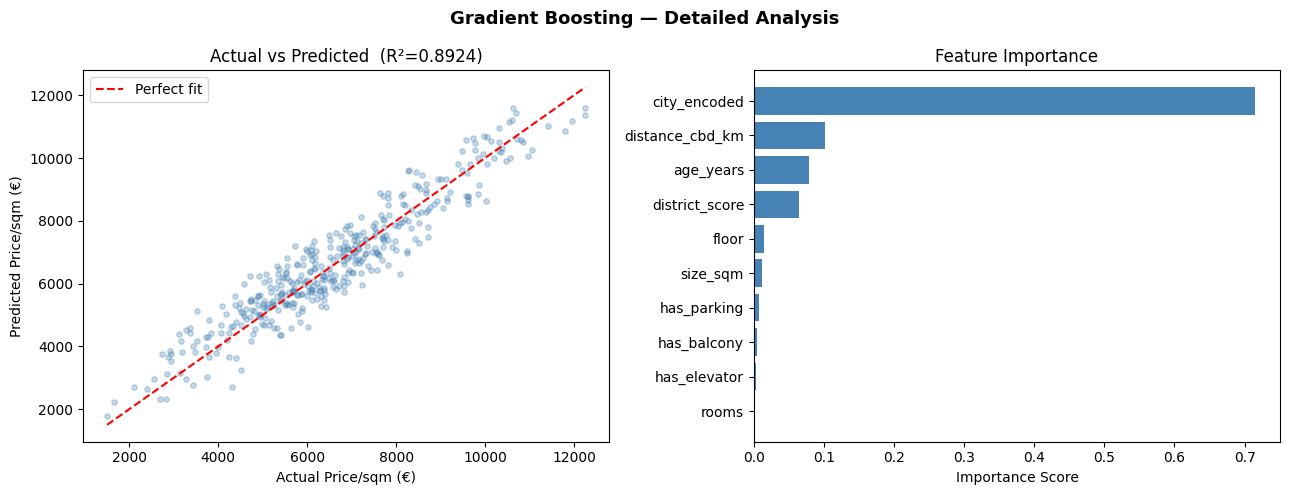

In [8]:
best_model = models['Gradient Boosting']
best_preds = results['Gradient Boosting']['preds']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Gradient Boosting — Detailed Analysis', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, best_preds, alpha=0.3, s=15, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price/sqm (€)')
axes[0].set_ylabel('Predicted Price/sqm (€)')
axes[0].set_title(f'Actual vs Predicted  (R²={results["Gradient Boosting"]["R2"]:.4f})')
axes[0].legend()

importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)
axes[1].barh(feat_imp.index, feat_imp.values, color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('outputs/best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Residual Analysis

Residuals are approximately normally distributed and centred near zero, with no systematic
pattern against predicted values — indicating no major structural bias in the model.

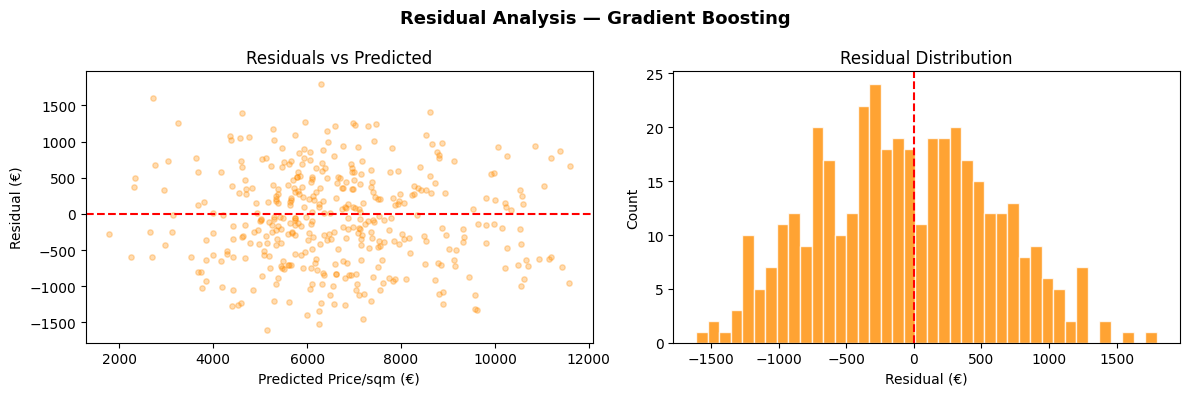

In [9]:
residuals = y_test.values - best_preds
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Residual Analysis — Gradient Boosting', fontsize=13, fontweight='bold')

axes[0].scatter(best_preds, residuals, alpha=0.3, s=15, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price/sqm (€)')
axes[0].set_ylabel('Residual (€)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (€)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('outputs/residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. City-Level Prediction Summary

Per-city accuracy is strongest in Hamburg and Munich (relatively homogeneous, high-demand
submarkets) and weakest in Düsseldorf, likely reflecting greater within-city heterogeneity in
district quality. Predicted means track actual means closely across all cities, indicating the
model is unbiased at the city level.

In [10]:
df_test = X_test.copy()
df_test['actual']    = y_test.values
df_test['predicted'] = best_preds
df_test['city'] = le.inverse_transform(df_test['city_encoded'])

city_metrics = df_test.groupby('city').apply(
    lambda g: pd.Series({
        'n': len(g),
        'actual_mean':    g['actual'].mean(),
        'predicted_mean': g['predicted'].mean(),
        'MAE':            mean_absolute_error(g['actual'], g['predicted']),
        'R2':             r2_score(g['actual'], g['predicted'])
    })
).round(2)
city_metrics

,n,actual_mean,predicted_mean,MAE,R2
city,,,,,
Berlin,83.0,5385.35,5453.69,553.36,0.65
Cologne,37.0,5837.19,5792.41,440.04,0.65
Düsseldorf,32.0,5848.99,6065.30,580.38,0.38
Frankfurt,60.0,7354.22,7063.78,571.31,0.62
Hamburg,63.0,6896.66,7030.68,494.65,0.79
Leipzig,31.0,3445.13,3588.82,553.85,0.51
Munich,60.0,9667.71,9902.64,572.82,0.71
Stuttgart,34.0,6589.69,6761.25,544.08,0.64


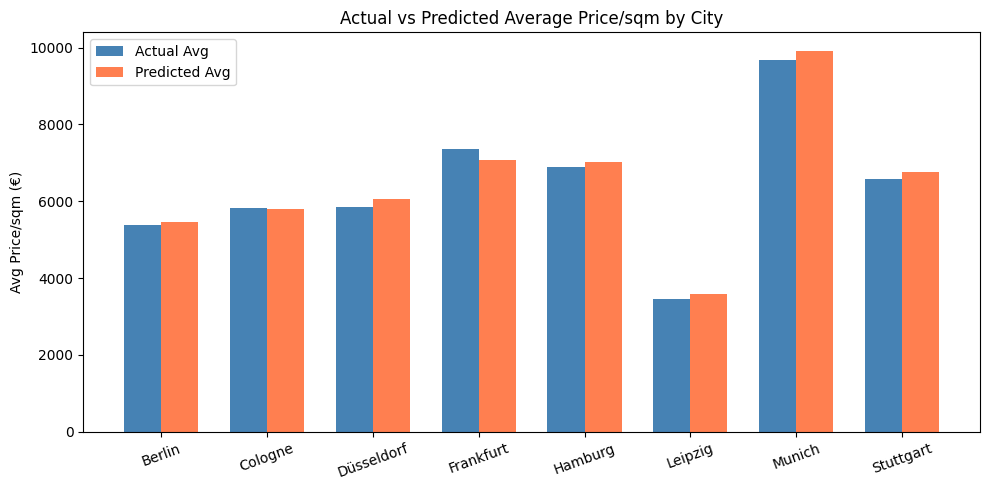

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(city_metrics))
w = 0.35
ax.bar(x - w/2, city_metrics['actual_mean'],    w, label='Actual Avg', color='steelblue')
ax.bar(x + w/2, city_metrics['predicted_mean'], w, label='Predicted Avg', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(city_metrics.index, rotation=20)
ax.set_ylabel('Avg Price/sqm (€)')
ax.set_title('Actual vs Predicted Average Price/sqm by City')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/city_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Summary

In [12]:
best = results['Gradient Boosting']
print("FINAL RESULTS SUMMARY")
print("=" * 40)
print(f"Best Model : Gradient Boosting Regressor")
print(f"R² Score   : {best['R2']:.4f}")
print(f"MAE        : €{best['MAE']:,.2f} per sqm")
print(f"RMSE       : €{best['RMSE']:,.2f} per sqm")

city_metrics.to_csv('outputs/city_prediction_results.csv')
df.to_csv('outputs/housing_dataset.csv', index=False)
print("\nSaved: outputs/city_prediction_results.csv, outputs/housing_dataset.csv")

FINAL RESULTS SUMMARY
Best Model : Gradient Boosting Regressor
R² Score   : 0.8924
MAE        : €540.65 per sqm
RMSE       : €653.16 per sqm

Saved: outputs/city_prediction_results.csv, outputs/housing_dataset.csv
